In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from matplotlib.ticker import MultipleLocator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


In [2]:
customers = pd.read_csv("enterprise_database/customers.csv")
financials = pd.read_csv("enterprise_database/financials.csv")
credit = pd.read_csv("enterprise_database/credit_profile.csv")
loans = pd.read_csv("enterprise_database/loans.csv")
risk = pd.read_csv("enterprise_database/risk_analysis.csv")
transactions = pd.read_csv("enterprise_database/transactions.csv")
txn_features = pd.read_csv("enterprise_database/transaction_features.csv")

In [3]:
for name, df in {
    "customers": customers,
    "financials": financials,
    "credit": credit,
    "loans": loans,
    "risk": risk,
    "transactions": transactions,
    "txn_features": txn_features
}.items():
    print(f"\n{name.upper()}")
    print(df.shape)
    print(df.head(2))
    print(f"\n{name.upper()} MISSING VALUES:")
    print(df.isnull().sum())


CUSTOMERS
(180000, 6)
   CustomerID  Age  Gender Marital_Status  Number_of_Dependents  \
0           1   43  Female       Divorced                     0   
1           2   36  Female        Married                     2   

  Education_Level  
0             PhD  
1     High School  

CUSTOMERS MISSING VALUES:
CustomerID              0
Age                     0
Gender                  0
Marital_Status          0
Number_of_Dependents    0
Education_Level         0
dtype: int64

FINANCIALS
(180000, 8)
   CustomerID Employment_Status      Job_Type  Years_Employed Income_Type  \
0           1          Employed  Construction              15      Salary   
1           2          Employed  Construction               4      Salary   

   Annual_Income  Monthly_Income  Income_Stability_Score  
0     1854580.38       149427.56                     100  
1      775901.11        62629.57                      64  

FINANCIALS MISSING VALUES:
CustomerID                    0
Employment_Status         

In [4]:
financials["Job_Type"] = financials["Job_Type"].fillna("Unemployed")
financials["Income_Type"] = financials["Income_Type"].fillna("No Income")

In [5]:
financials["Employment_Status"].value_counts()
financials["Job_Type"].value_counts()
financials["Income_Type"].value_counts()

Income_Type
Salary       117091
Business      31375
No Income     18162
Freelance     13372
Name: count, dtype: int64

In [6]:
financials.isnull().sum()

CustomerID                0
Employment_Status         0
Job_Type                  0
Years_Employed            0
Income_Type               0
Annual_Income             0
Monthly_Income            0
Income_Stability_Score    0
dtype: int64

In [7]:
print(customers["CustomerID"].nunique() == len(customers))


True


In [8]:
print(loans["CustomerID"].isin(customers["CustomerID"]).all())
print(financials["CustomerID"].isin(customers["CustomerID"]).all())

True
True


In [9]:
financials["Monthly_Income"].describe()

count    180000.000000
mean      82631.364019
std       54136.981513
min       10000.000000
25%       47320.202500
50%       72105.580000
75%      105577.440000
max      350000.000000
Name: Monthly_Income, dtype: float64

In [10]:
credit["Credit_Score"].describe()

count    180000.000000
mean        692.510872
std          87.776185
min         336.000000
25%         635.000000
50%         704.000000
75%         761.000000
max         849.000000
Name: Credit_Score, dtype: float64

In [11]:
loans["Loan_Amount"].describe()

count    2.500000e+05
mean     6.925524e+05
std      6.329189e+05
min      1.201449e+04
25%      2.915286e+05
50%      5.197245e+05
75%      8.843594e+05
max      1.149110e+07
Name: Loan_Amount, dtype: float64

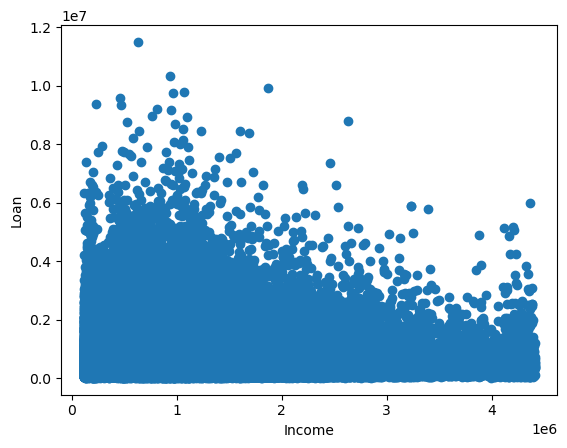

In [12]:
plt.scatter(financials["Annual_Income"], loans["Loan_Amount"][:len(financials)])
plt.xlabel("Income")
plt.ylabel("Loan")
plt.show()

In [13]:
merged = risk.merge(credit, on="CustomerID")

merged.groupby("Default_Status")["Credit_Score"].mean()

Default_Status
0    705.693591
1    648.184228
Name: Credit_Score, dtype: float64

In [14]:
risk.groupby("Default_Status")["Debt_to_Income_Ratio"].mean()

Default_Status
0    0.243344
1    0.433689
Name: Debt_to_Income_Ratio, dtype: float64

In [15]:
transactions.groupby("CustomerID").size().describe()

count    180000.000000
mean         50.122033
std          10.255949
min          26.000000
25%          40.000000
50%          54.000000
75%          59.000000
max          78.000000
dtype: float64

In [16]:
transactions[transactions["Is_Salary"] == 1].groupby("CustomerID").size().describe()

count    180000.0
mean         24.0
std           0.0
min          24.0
25%          24.0
50%          24.0
75%          24.0
max          24.0
dtype: float64

In [17]:
transactions["Account_Balance"].describe()

count    9.021966e+06
mean     9.476391e+05
std      8.414371e+05
min      1.554129e+04
25%      3.538681e+05
50%      7.245920e+05
75%      1.268350e+06
max      9.024249e+06
Name: Account_Balance, dtype: float64

In [18]:
financials["Monthly_Income"].quantile([0.01, 0.99])
loans["Loan_Amount"].quantile([0.01, 0.99])

0.01    5.412732e+04
0.99    3.101443e+06
Name: Loan_Amount, dtype: float64

In [19]:

import sqlite3

# Connect to database
conn = sqlite3.connect("loan_risk.db")

# Write to SQL tables
customers.to_sql("customers", conn, if_exists="replace", index=False)
financials.to_sql("financials", conn, if_exists="replace", index=False)
credit.to_sql("credit_profile", conn, if_exists="replace", index=False)
loans.to_sql("loans", conn, if_exists="replace", index=False)
risk.to_sql("risk_analysis", conn, if_exists="replace", index=False)
txn_features.to_sql("transaction_features", conn, if_exists="replace", index=False)

print("✅ All tables loaded into SQL!")

✅ All tables loaded into SQL!


In [20]:
cursor = conn.cursor()

In [21]:
with open("SQL/sql_queries.sql", "r") as file:
    sql_script = file.read()

In [22]:
conn.commit()

cursor.executescript(sql_script)

In [23]:
final_df = pd.read_sql("SELECT * FROM final_dataset", conn)

print(final_df.shape)
final_df.head()


(250000, 39)


,LoanID,CustomerID,Loan_Amount,Loan_Term_Months,Interest_Rate,EMI,Loan_Purpose,Application_Channel,Age,Gender,...,Debt_to_Income_Ratio,High_Risk_Flag,Low_Income_Flag,High_Loan_Flag,Default_Status,avg_monthly_spending,spending_to_income_ratio,balance_volatility,rent_payment_ratio,behavioral_risk_score
0,1,116520,198623.96,36,6.33,6072.27,Business,Agent,41,Female,...,0.080,0,0,0,0,3269.019167,0.040317,558023.800677,0.000000,1.932618
1,2,143688,426373.30,60,12.01,9486.59,Education,Online,43,Male,...,0.395,1,0,0,1,1758.252500,0.049674,263130.699420,0.000000,2.073379
2,3,136052,888823.32,72,7.72,15462.72,Business,Branch,40,Male,...,0.317,0,0,1,0,15559.747143,0.276011,319478.098999,0.791667,1.541256
3,4,147736,514441.22,60,6.74,10123.57,Medical,Agent,42,Male,...,0.156,1,0,0,0,3289.425833,0.046491,458332.950546,0.000000,1.833419
4,5,156914,718115.29,36,6.61,22045.49,Car,Agent,32,Female,...,0.312,0,0,0,0,23751.291739,0.316791,360240.091908,0.750000,1.346246


In [24]:
final_df["behavioral_risk_score"] = (
    final_df["behavioral_risk_score"] - final_df["behavioral_risk_score"].min()
) / (
    final_df["behavioral_risk_score"].max() - final_df["behavioral_risk_score"].min()
)

In [25]:
final_df["behavioral_risk_score"].describe()

count    250000.000000
mean          0.435726
std           0.241604
min           0.000000
25%           0.229548
50%           0.314994
75%           0.697236
max           1.000000
Name: behavioral_risk_score, dtype: float64

In [26]:
final_df["Default_Status"].value_counts(normalize=True)

Default_Status
0    0.76896
1    0.23104
Name: proportion, dtype: float64

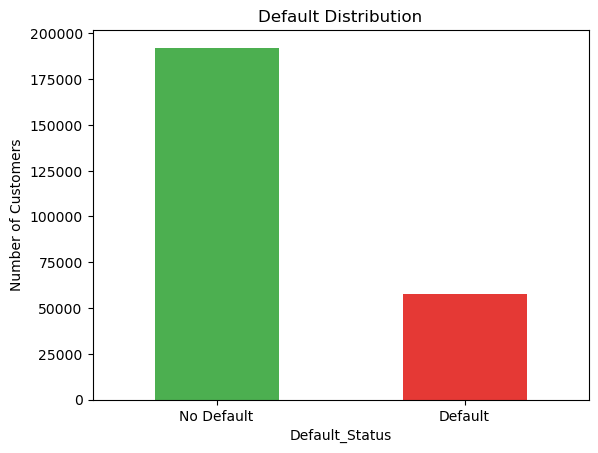

In [27]:
final_df["Default_Status"].value_counts().plot(
    kind="bar",
    color=["#4CAF50", "#E53935"]   # Green = No Default, Red = Default
)

plt.title("Default Distribution")
plt.xticks([0, 1], ["No Default", "Default"], rotation=0)
plt.ylabel("Number of Customers")
plt.show()

In [28]:
query = """
SELECT 
    CASE 
        WHEN Monthly_Income < 30000 THEN 'Low'
        WHEN Monthly_Income < 80000 THEN 'Medium'
        ELSE 'High'
    END AS income_group,
    COUNT(*) AS total_loans,
    AVG(Default_Status) AS default_rate
FROM final_dataset
GROUP BY income_group
"""

df_income = pd.read_sql(query, conn)
df_income

,income_group,total_loans,default_rate
0,High,107292,0.221312
1,Low,31980,0.271920
2,Medium,110728,0.228659


In [29]:
query = """
SELECT 
    ROUND(Credit_Score / 50) * 50 AS score_bucket,
    AVG(Default_Status) AS default_rate
FROM final_dataset
GROUP BY score_bucket
ORDER BY score_bucket
"""

df_credit = pd.read_sql(query, conn)
df_credit

,score_bucket,default_rate
0,300.0,0.687500
1,350.0,0.714286
2,400.0,0.613793
3,450.0,0.568493
4,500.0,0.553069
5,550.0,0.518527
6,600.0,0.217907
7,650.0,0.193392
8,700.0,0.168801
9,750.0,0.151764


In [30]:
query = """
SELECT 
    Loan_Purpose,
    AVG(Default_Status) AS default_rate
FROM final_dataset
GROUP BY Loan_Purpose
ORDER BY default_rate DESC
"""

df_purpose = pd.read_sql(query, conn)
df_purpose

,Loan_Purpose,default_rate
0,Business,0.233854
1,Personal,0.232316
2,Medical,0.231214
3,Education,0.230650
4,Home,0.229720
5,Car,0.229108


In [31]:
query1 = """
SELECT 
    CASE 
        WHEN Monthly_Income < 30000 THEN 'Low'
        WHEN Monthly_Income < 80000 THEN 'Medium'
        ELSE 'High'
    END AS income_group,

    ROUND(Credit_Score / 50) * 50 AS score_bucket,

    AVG(Default_Status) AS default_rate

FROM final_dataset

GROUP BY 
    CASE 
        WHEN Monthly_Income < 30000 THEN 'Low'
        WHEN Monthly_Income < 80000 THEN 'Medium'
        ELSE 'High'
    END,
    ROUND(Credit_Score / 50) * 50
"""

df_purpose1 = pd.read_sql(query1, conn)
df_purpose1

,income_group,score_bucket,default_rate
0,High,300.0,1.000000
1,High,350.0,0.696429
2,High,400.0,0.627389
3,High,450.0,0.550962
4,High,500.0,0.536799
5,High,550.0,0.511028
6,High,600.0,0.201945
7,High,650.0,0.183281
8,High,700.0,0.161793
9,High,750.0,0.139520


In [32]:
final_df.shape
final_df.head()

,LoanID,CustomerID,Loan_Amount,Loan_Term_Months,Interest_Rate,EMI,Loan_Purpose,Application_Channel,Age,Gender,...,Debt_to_Income_Ratio,High_Risk_Flag,Low_Income_Flag,High_Loan_Flag,Default_Status,avg_monthly_spending,spending_to_income_ratio,balance_volatility,rent_payment_ratio,behavioral_risk_score
0,1,116520,198623.96,36,6.33,6072.27,Business,Agent,41,Female,...,0.080,0,0,0,0,3269.019167,0.040317,558023.800677,0.000000,0.730697
1,2,143688,426373.30,60,12.01,9486.59,Education,Online,43,Male,...,0.395,1,0,0,1,1758.252500,0.049674,263130.699420,0.000000,0.850595
2,3,136052,888823.32,72,7.72,15462.72,Business,Branch,40,Male,...,0.317,0,0,1,0,15559.747143,0.276011,319478.098999,0.791667,0.397340
3,4,147736,514441.22,60,6.74,10123.57,Medical,Agent,42,Male,...,0.156,1,0,0,0,3289.425833,0.046491,458332.950546,0.000000,0.646200
4,5,156914,718115.29,36,6.61,22045.49,Car,Agent,32,Female,...,0.312,0,0,0,0,23751.291739,0.316791,360240.091908,0.750000,0.231233


In [33]:
final_df.describe()

,LoanID,CustomerID,Loan_Amount,Loan_Term_Months,Interest_Rate,EMI,Age,Number_of_Dependents,Years_Employed,Annual_Income,...,Debt_to_Income_Ratio,High_Risk_Flag,Low_Income_Flag,High_Loan_Flag,Default_Status,avg_monthly_spending,spending_to_income_ratio,balance_volatility,rent_payment_ratio,behavioral_risk_score
count,250000.000000,250000.000000,2.500000e+05,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,2.500000e+05,...,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,2.500000e+05,250000.000000,250000.000000
mean,125000.500000,90107.587344,6.925524e+05,86.906016,9.452956,18263.357701,37.756740,0.882408,7.646056,1.007388e+06,...,0.287321,0.280108,0.110164,0.159956,0.231040,18061.463091,0.218452,4.687685e+05,0.479031,0.435726
std,72168.927986,52018.458876,6.329189e+05,87.039134,2.756163,23419.268468,11.457539,1.138533,8.260070,6.608699e+05,...,0.215499,0.449053,0.313095,0.366566,0.421499,18619.485015,0.145011,3.230685e+05,0.397184,0.241604
min,1.000000,1.000000,1.201449e+04,12.000000,5.000000,180.770000,18.000000,0.000000,0.000000,1.176070e+05,...,0.015000,0.000000,0.000000,0.000000,0.000000,267.133636,0.013170,4.022490e+04,0.000000,0.000000
25%,62500.750000,45096.750000,2.915286e+05,36.000000,7.460000,5580.950000,29.000000,0.000000,1.000000,5.764737e+05,...,0.152000,0.000000,0.000000,0.000000,0.000000,3953.954208,0.051433,2.564584e+05,0.000000,0.229548
50%,125000.500000,90266.500000,5.197245e+05,60.000000,8.980000,11334.750000,38.000000,0.000000,5.000000,8.800397e+05,...,0.229000,0.000000,0.000000,0.000000,0.000000,12294.276957,0.273849,4.011838e+05,0.708333,0.314994
75%,187500.250000,135142.250000,8.843594e+05,72.000000,10.800000,21982.275000,46.000000,1.000000,12.000000,1.284193e+06,...,0.350000,1.000000,0.000000,0.000000,0.000000,26661.755031,0.343862,6.007003e+05,0.833333,0.697236
max,250000.000000,180000.000000,1.149110e+07,360.000000,23.660000,822926.560000,80.000000,9.000000,58.000000,4.409681e+06,...,2.500000,1.000000,1.000000,1.000000,1.000000,176139.704444,0.595207,2.723325e+06,1.000000,1.000000


In [34]:
final_df.groupby("Loan_Purpose")["Default_Status"].mean()

Loan_Purpose
Business     0.233854
Car          0.229108
Education    0.230650
Home         0.229720
Medical      0.231214
Personal     0.232316
Name: Default_Status, dtype: float64

In [35]:
final_df.groupby("Loan_Purpose").size()

Loan_Purpose
Business     37874
Car          49649
Education    25090
Home         62659
Medical      12283
Personal     62445
dtype: int64

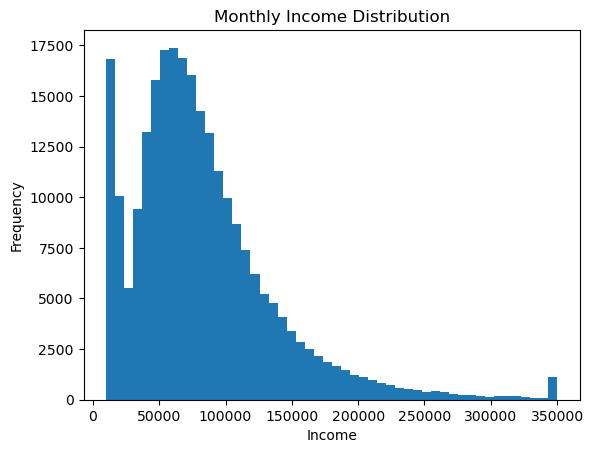

In [36]:
plt.hist(final_df["Monthly_Income"], bins=50)
plt.title("Monthly Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

 Monthly income exhibits a **right-skewed distribution**, with the majority of customers earning between **₹40,000 and ₹100,000** per month.
 A smaller proportion of customers fall into the higher-income brackets, creating a long right tail.

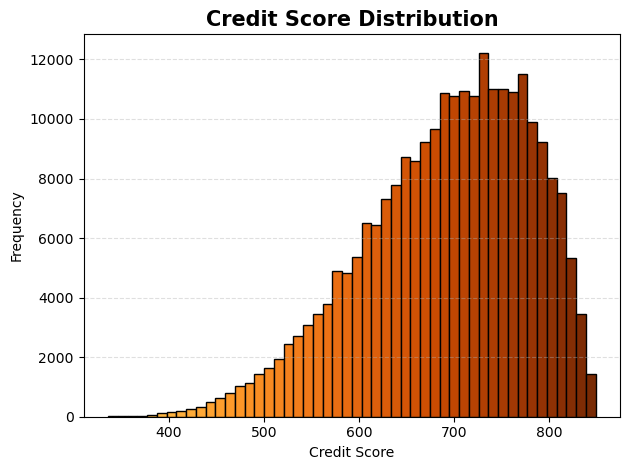

In [37]:
counts, bins, patches = plt.hist(
    final_df["Credit_Score"],
    bins=50,
    edgecolor="black"
)

colors = plt.cm.YlOrBr(np.linspace(0.35, 0.95, len(patches)))

for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

plt.title("Credit Score Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Credit scores are concentrated between **650 and 800**, indicating that most applicants possess **good to excellent creditworthiness**.
Relatively few customers have credit scores below 500, representing the high-risk borrower segment.


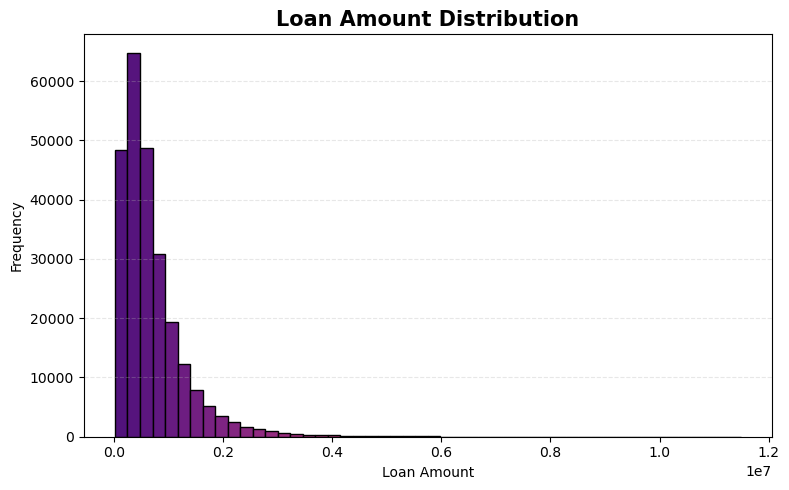

In [38]:
plt.figure(figsize=(8,5))

counts, bins, patches = plt.hist(
    final_df["Loan_Amount"],
    bins=50,
    edgecolor="black"
)

# Orange gradient (light → dark)
colors = plt.cm.magma(np.linspace(0.25, 0.95, len(patches)))

for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

plt.title("Loan Amount Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Loan amounts display a **positively skewed distribution**, with most loans belonging to the lower and medium-value ranges.
Only a small percentage of customers receive very high-value loans, resulting in a long right tail.

### Key Observations (Univariate Analysis)

1. Higher-income customers are comparatively fewer, while average-income customers constitute the majority of the portfolio.
2. Credit scores are predominantly clustered within safer ranges, producing a balanced mix of low-risk and high-risk borrowers suitable for predictive modeling.
3. These distributions provide a strong foundation for training machine learning models to identify loan default risk and customer segmentation.

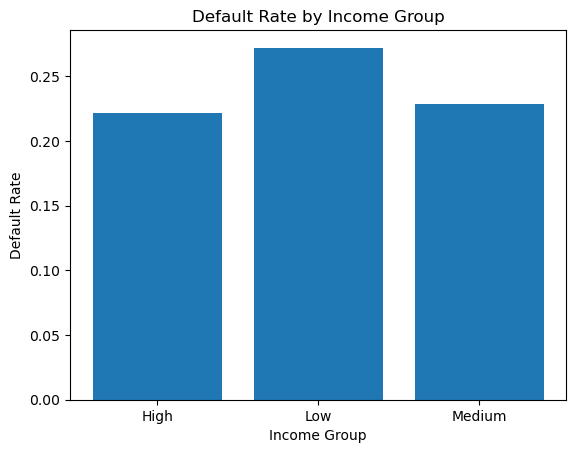

In [40]:
plt.bar(df_income["income_group"], df_income["default_rate"])
plt.title("Default Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Default Rate")
plt.show()

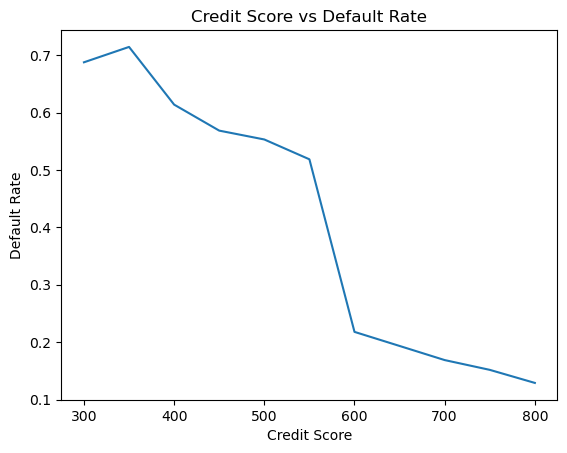

In [41]:
plt.plot(df_credit["score_bucket"], df_credit["default_rate"])
plt.title("Credit Score vs Default Rate")
plt.xlabel("Credit Score")
plt.ylabel("Default Rate")
plt.show()

In [42]:
final_df["loan_bin"] = pd.qcut(final_df["Loan_Amount"], q=4, labels=["Low", "Medium", "High", "Very High"])

In [43]:
loan_analysis = final_df.groupby("loan_bin")["Default_Status"].mean().reset_index()
loan_analysis

C:\Users\Krishna\AppData\Local\Temp\ipykernel_3460\1640227306.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_analysis = final_df.groupby("loan_bin")["Default_Status"].mean().reset_index()


,loan_bin,Default_Status
0,Low,0.218000
1,Medium,0.206064
2,High,0.225664
3,Very High,0.274432


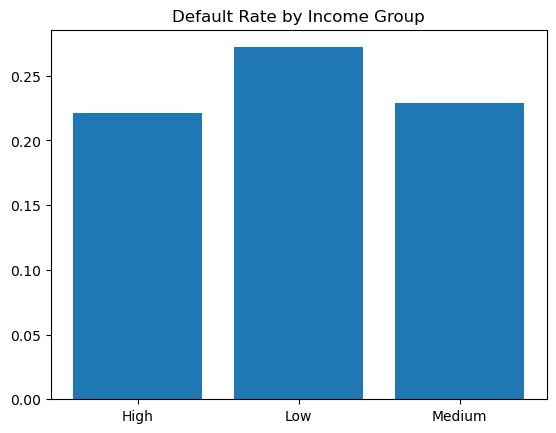

In [44]:
plt.bar(df_income["income_group"], df_income["default_rate"])
plt.title("Default Rate by Income Group")
plt.show()

In [45]:
final_df["dti_bin"] = pd.qcut(final_df["Debt_to_Income_Ratio"], q=4)
dti_analysis = final_df.groupby("dti_bin")["Default_Status"].mean().reset_index()
dti_analysis

C:\Users\Krishna\AppData\Local\Temp\ipykernel_3460\2332869884.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dti_analysis = final_df.groupby("dti_bin")["Default_Status"].mean().reset_index()


,dti_bin,Default_Status
0,"(0.013999999999999999, 0.152]",0.079196
1,"(0.152, 0.229]",0.163122
2,"(0.229, 0.35]",0.236950
3,"(0.35, 2.5]",0.445942


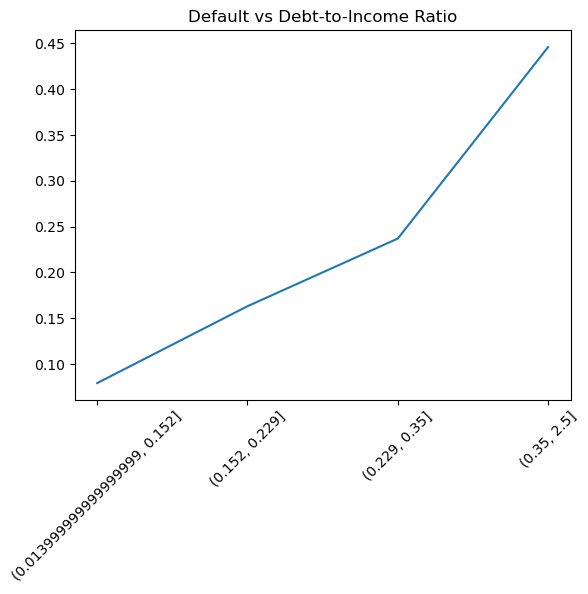

In [46]:
plt.plot(dti_analysis["dti_bin"].astype(str), dti_analysis["Default_Status"])
plt.xticks(rotation=45)
plt.title("Default vs Debt-to-Income Ratio")
plt.show()

In [47]:
final_df["behavior_bin"] = pd.qcut(final_df["behavioral_risk_score"], q=3, labels=["Low", "Medium", "High"])
behavior_analysis = final_df.groupby("behavior_bin")["Default_Status"].mean().reset_index()
behavior_analysis

C:\Users\Krishna\AppData\Local\Temp\ipykernel_3460\2416026567.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  behavior_analysis = final_df.groupby("behavior_bin")["Default_Status"].mean().reset_index()


,behavior_bin,Default_Status
0,Low,0.183839
1,Medium,0.217133
2,High,0.292152


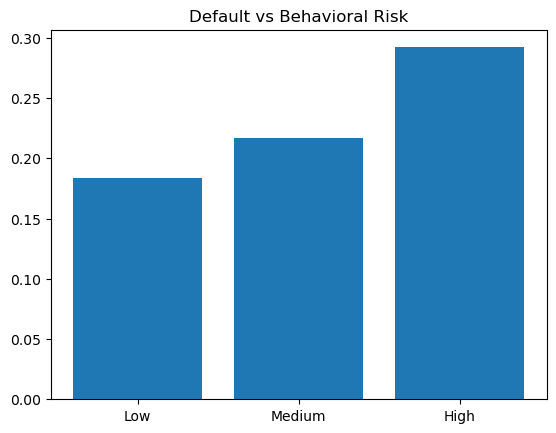

In [48]:
plt.bar(behavior_analysis["behavior_bin"], behavior_analysis["Default_Status"])
plt.title("Default vs Behavioral Risk")
plt.show()

In [49]:
def segment_customer(row):

    if row["behavioral_risk_score"] > 0.75:
        return "Behavioral Risk"

    elif row["Credit_Score"] < 580:
        return "Credit Risk"

    elif row["EMI_to_Income_Ratio"] > 0.6:
        return "Financial Stress"

    elif row["Loan_to_Income_Ratio"] > 1.2:
        return "High Exposure"

    else:
        return "Low Risk"

# Apply
final_df["customer_segment"] = final_df.apply(segment_customer, axis=1)

final_df["customer_segment"].value_counts()

customer_segment
Low Risk            170046
Behavioral Risk      32494
Credit Risk          25542
High Exposure        12871
Financial Stress      9047
Name: count, dtype: int64

In [50]:
segment_analysis = final_df.groupby("customer_segment")["Default_Status"].mean().sort_values(ascending=False)
segment_analysis

customer_segment
Financial Stress    0.595778
Credit Risk         0.534649
Behavioral Risk     0.312827
High Exposure       0.233082
Low Risk            0.150248
Name: Default_Status, dtype: float64

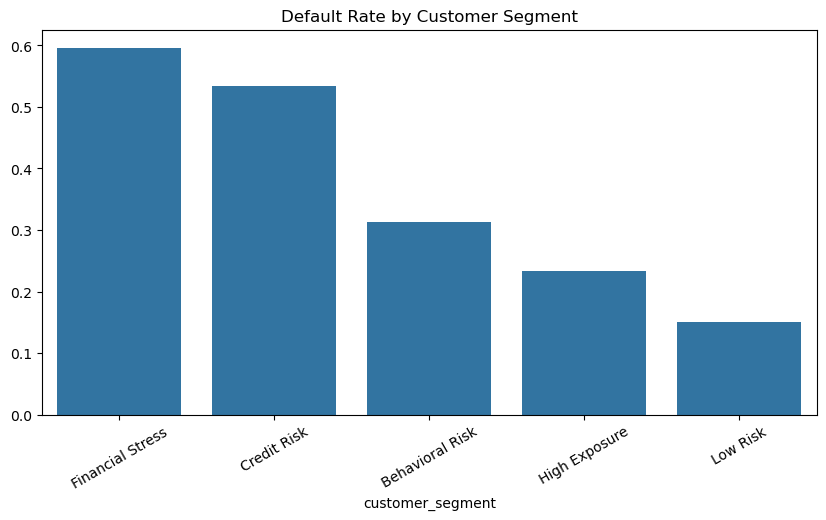

In [51]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=segment_analysis.index,
    y=segment_analysis.values
)
plt.xticks(rotation=30)
plt.title("Default Rate by Customer Segment")
plt.show()

### Key Insight

Customers classified under **Financial Stress (59.6%)** and **Credit Risk (53.5%)** exhibit the highest default rates, making them the most vulnerable borrower segments.

Behavioral Risk customers also show a notable default rate (**31.3%**), indicating that transactional behavior provides valuable predictive signals beyond traditional financial indicators.

These findings demonstrate that combining **credit history, financial health, and behavioral transaction patterns** enables more accurate loan default prediction than relying solely on conventional credit scores.

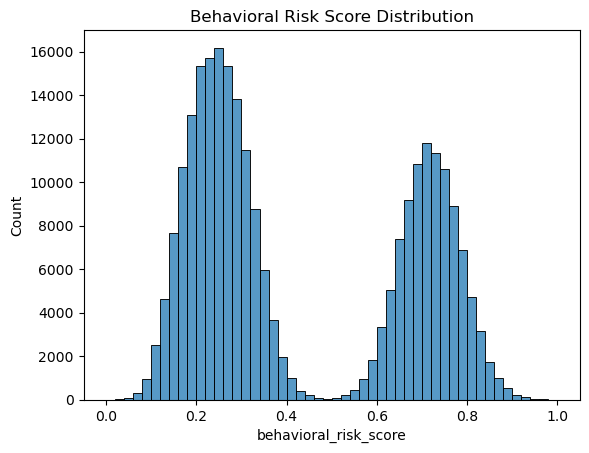

In [52]:
sns.histplot(final_df["behavioral_risk_score"], bins=50)
plt.title("Behavioral Risk Score Distribution")
plt.show()

In [53]:
final_df.shape

(250000, 43)

In [54]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   LoanID                    250000 non-null  int64   
 1   CustomerID                250000 non-null  int64   
 2   Loan_Amount               250000 non-null  float64 
 3   Loan_Term_Months          250000 non-null  int64   
 4   Interest_Rate             250000 non-null  float64 
 5   EMI                       250000 non-null  float64 
 6   Loan_Purpose              250000 non-null  object  
 7   Application_Channel       250000 non-null  object  
 8   Age                       250000 non-null  int64   
 9   Gender                    250000 non-null  object  
 10  Marital_Status            250000 non-null  object  
 11  Number_of_Dependents      250000 non-null  int64   
 12  Education_Level           250000 non-null  object  
 13  Employment_Status         250

In [55]:
final_df.head()

,LoanID,CustomerID,Loan_Amount,Loan_Term_Months,Interest_Rate,EMI,Loan_Purpose,Application_Channel,Age,Gender,...,Default_Status,avg_monthly_spending,spending_to_income_ratio,balance_volatility,rent_payment_ratio,behavioral_risk_score,loan_bin,dti_bin,behavior_bin,customer_segment
0,1,116520,198623.96,36,6.33,6072.27,Business,Agent,41,Female,...,0,3269.019167,0.040317,558023.800677,0.000000,0.730697,Low,"(0.013999999999999999, 0.152]",High,Low Risk
1,2,143688,426373.30,60,12.01,9486.59,Education,Online,43,Male,...,1,1758.252500,0.049674,263130.699420,0.000000,0.850595,Medium,"(0.35, 2.5]",High,Behavioral Risk
2,3,136052,888823.32,72,7.72,15462.72,Business,Branch,40,Male,...,0,15559.747143,0.276011,319478.098999,0.791667,0.397340,Very High,"(0.229, 0.35]",Medium,High Exposure
3,4,147736,514441.22,60,6.74,10123.57,Medical,Agent,42,Male,...,0,3289.425833,0.046491,458332.950546,0.000000,0.646200,Medium,"(0.152, 0.229]",Medium,Low Risk
4,5,156914,718115.29,36,6.61,22045.49,Car,Agent,32,Female,...,0,23751.291739,0.316791,360240.091908,0.750000,0.231233,High,"(0.229, 0.35]",Low,Low Risk


In [56]:
final_df.to_csv("data/credit_risk_final.csv", index=False)

print("✅ Exported successfully")

✅ Exported successfully
